In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Read dataset
df = df = pd.read_csv(r'C:\Users\Niran\Downloads\car_prices.csv')

# Display first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Display data types and record count
print("\n--- Data Info & Record Count ---")
df.info()

--- First 5 Rows ---


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)



--- Data Info & Record Count ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB

In [3]:
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Column names and data types
print("\nColumn Data Types:")
print(df.dtypes)

Dataset Shape: 558837 rows x 16 columns

Column Data Types:
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


In [4]:
# 1. Quantify nulls per column
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

              Null Count  Percentage (%)
year                   0        0.000000
make               10301        1.843292
model              10399        1.860829
trim               10651        1.905922
body               13195        2.361154
transmission       65352       11.694287
vin                    4        0.000716
state                  0        0.000000
condition          11820        2.115107
odometer              94        0.016821
color                749        0.134028
interior             749        0.134028
seller                 0        0.000000
mmr                   38        0.006800
sellingprice          12        0.002147
saledate              12        0.002147


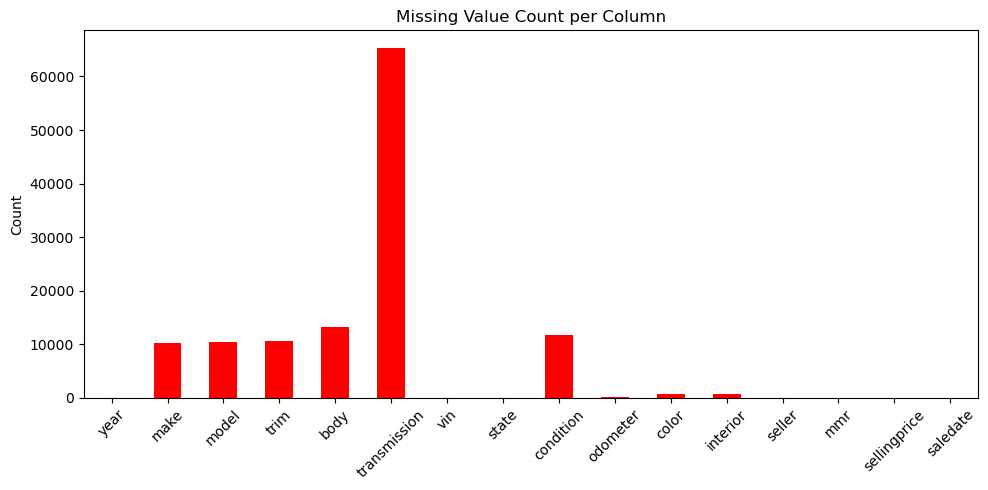

In [5]:
# 2. Visualize missing values with a bar chart
plt.figure(figsize=(10, 5))
null_summary['Null Count'].plot(kind='bar', color='red')
plt.title('Missing Value Count per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Fill all default categoricals at once
categorical_defaults = {col: 'Unknown' for col in ['make', 'model', 'trim', 'body', 'color', 'interior']}

In [7]:
# 3. Check and delete duplicate records
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Records: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Total Duplicate Records: 0


In [8]:
avg_price = df['sellingprice'].mean()
min_price = df['sellingprice'].min()
max_price = df['sellingprice'].max()

print(f"Average Selling Price: ${avg_price:,.2f}")
print(f"Minimum Selling Price: ${min_price:,.2f}")
print(f"Maximum Selling Price: ${max_price:,.2f}")

Average Selling Price: $13,611.36
Minimum Selling Price: $1.00
Maximum Selling Price: $230,000.00


In [9]:
unique_colors = df['color'].dropna().unique()
print(f"Unique Colors ({len(unique_colors)} total):")
print(unique_colors)

Unique Colors (46 total):
['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime' '4802' '9410' '1167' '2172' '14872' '12655'
 '15719' '6388' '16633' '11034' '2711' '6864' '339' '18384' '9887' '9837'
 '20379' '20627' '721' '6158' '2817' '5705' '18561' '2846' '9562' '5001']


In [10]:
num_makes = df['make'].nunique()
num_models = df['model'].nunique()

print(f"Unique Car Brands (Makes): {num_makes}")
print(f"Unique Car Models: {num_models}")

Unique Car Brands (Makes): 96
Unique Car Models: 973


In [11]:
expensive_cars = df[df['sellingprice'] > 165000]
print(f"Number of cars > $165,000: {len(expensive_cars)}")
display(expensive_cars[['year', 'make', 'model', 'trim', 'sellingprice']])

Number of cars > $165,000: 7


,year,make,model,trim,sellingprice
125095,2012,Rolls-Royce,Ghost,Base,169500.0
344905,2014,Ford,Escape,Titanium,230000.0
446949,2015,Mercedes-Benz,S-Class,S65 AMG,173000.0
538347,2012,Rolls-Royce,Ghost,Base,167000.0
545523,2013,Rolls-Royce,Ghost,Base,171500.0
548169,2011,Ferrari,458 Italia,Base,183000.0
557570,2012,Rolls-Royce,Ghost,EWB,169000.0


In [12]:
top_5_models = df['model'].value_counts().head(5)
print("Top 5 Most Frequently Sold Car Models:")
print(top_5_models)

Top 5 Most Frequently Sold Car Models:
model
Altima    19349
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64


In [13]:
avg_price_by_brand = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)
print("Top 10 Highest Average Selling Price Brands:")
print(avg_price_by_brand.head(10))

Top 10 Highest Average Selling Price Brands:
make
Rolls-Royce     153488.235294
Ferrari         127210.526316
Lamborghini     112625.000000
Bentley          74367.672414
airstream        71000.000000
Tesla            67054.347826
Aston Martin     54812.000000
Fisker           46461.111111
Maserati         45320.300752
Lotus            40800.000000
Name: sellingprice, dtype: float64


In [14]:
min_price_interior = df.groupby('interior')['sellingprice'].min()
print("Minimum Selling Price by Interior:")
print(min_price_interior)

Minimum Selling Price by Interior:
interior
beige         100.0
black           1.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            1.0
green         100.0
off-white     900.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
—             150.0
Name: sellingprice, dtype: float64


In [15]:
highest_odo_per_year = df.groupby('year')['odometer'].max().sort_values(ascending=False)
print("Highest Odometer Reading per Year:")
print(highest_odo_per_year.head(10))

Highest Odometer Reading per Year:
year
1999    999999.0
2013    999999.0
2011    999999.0
2010    999999.0
2009    999999.0
2008    999999.0
2007    999999.0
2006    999999.0
2005    999999.0
2004    999999.0
Name: odometer, dtype: float64


In [16]:
df['car_age'] = 2025 - df['year']
print(df[['year', 'car_age']].head())

   year  car_age
0  2015       10
1  2015       10
2  2014       11
3  2015       10
4  2014       11


In [17]:
cond_odo_filtered = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
print(f"Number of cars meeting criteria: {len(cond_odo_filtered)}")

Number of cars meeting criteria: 746


In [18]:
newer_cars = df[df['year'] > 2013]
state_prices = newer_cars.groupby('state')['sellingprice'].agg(['mean', 'median', 'count'])
top_states = state_prices[state_prices['count'] > 100].sort_values(by='mean', ascending=False)

print("Top States for Newer Cars (> 2013) by Mean Price:")
print(top_states.head(5))

Top States for Newer Cars (> 2013) by Mean Price:
               mean   median  count
state                              
oh     28020.221053  22600.0   2755
ab     25204.255319  25000.0    141
nj     24237.063973  20500.0   3267
on     22962.560386  21500.0   1863
qc     22722.938144  22200.0    388


In [19]:
pct_80_condition = df['condition'].quantile(0.80)
excellent_cars = df[df['condition'] >= pct_80_condition]

value_makes = excellent_cars.groupby('make')['sellingprice'].agg(['mean', 'count'])
value_makes = value_makes[value_makes['count'] >= 10].sort_values(by='mean', ascending=True)

print(f"Top 80th Percentile Condition Threshold: {pct_80_condition}")
print("Lowest Average Price Brands in Excellent Condition (Value for Money):")
print(value_makes.head(10))

Top 80th Percentile Condition Threshold: 43.0
Lowest Average Price Brands in Excellent Condition (Value for Money):
                    mean  count
make                           
Saturn       5700.406504    123
smart        6835.759494    158
Pontiac      7686.824324    148
Saab         7711.111111     18
Suzuki       8409.615385     26
Mercury      9031.770833     96
FIAT        11655.293269    208
Scion       13327.186312    263
ford        13671.428571     28
Mitsubishi  14468.125000    560


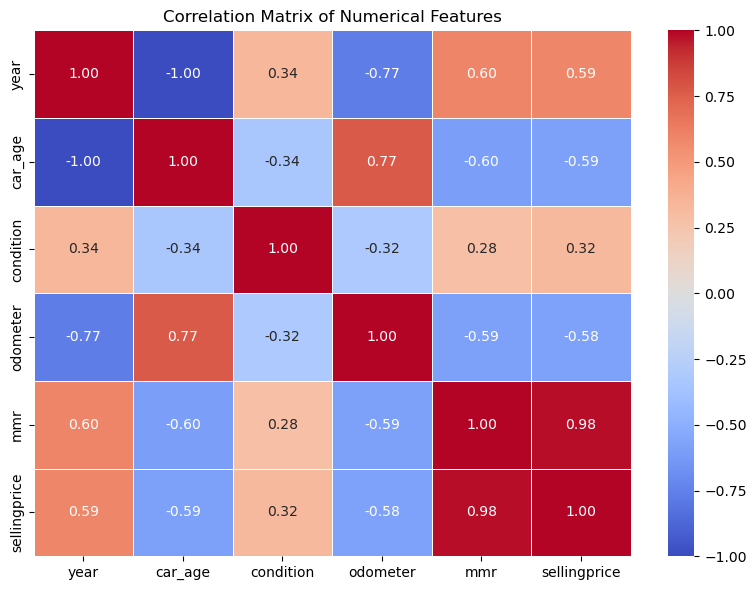

In [20]:
plt.figure(figsize=(8, 6))
num_cols = ['year', 'car_age', 'condition', 'odometer', 'mmr', 'sellingprice']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
3.2 Average Selling Price by Year (Bar vs. Scatter
                                   

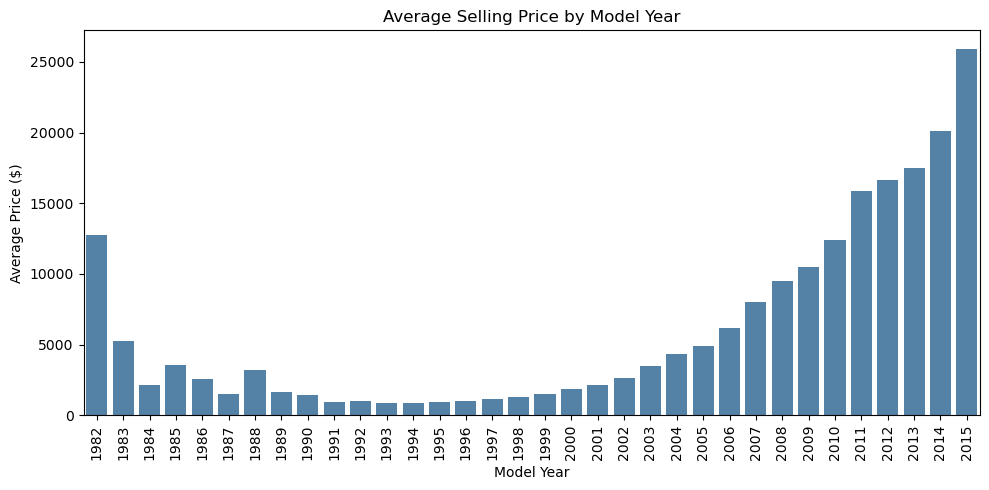

In [28]:
plt.figure(figsize=(10, 5))
avg_price_year = df.groupby('year')['sellingprice'].mean()
sns.barplot(x=avg_price_year.index, y=avg_price_year.values, color='steelblue')
plt.xticks(rotation=90)
plt.title("Average Selling Price by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average Price ($)")
plt.tight_layout()
plt.show()

In [ ]:
Average Selling Price by Odometer

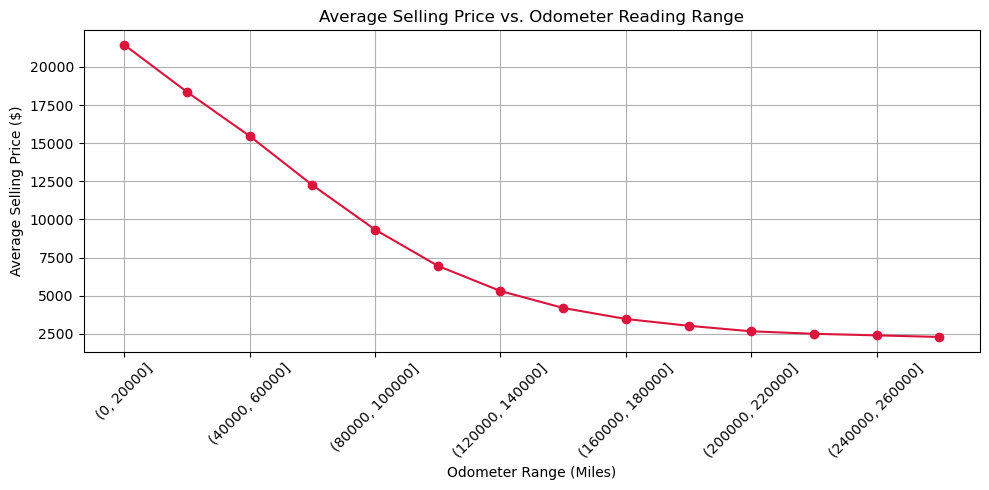

In [27]:
df['odometer_bin'] = pd.cut(df['odometer'], bins=range(0, 300000, 20000))
odo_trend = df.groupby('odometer_bin', observed=False)['sellingprice'].mean()

plt.figure(figsize=(10, 5))
odo_trend.plot(kind='line', marker='o', color='crimson')
plt.title("Average Selling Price vs. Odometer Reading Range")
plt.xlabel("Odometer Range (Miles)")
plt.ylabel("Average Selling Price ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Number of Cars Sold by State (Top 3 Selling States)

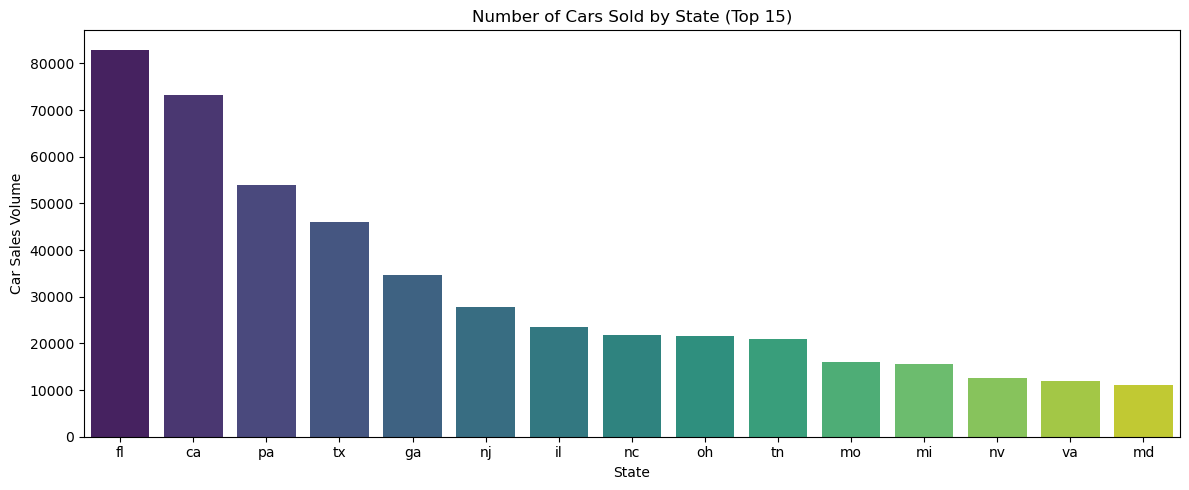

Top 3 Highest Car Selling States:
state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
top_states_count = df['state'].value_counts().head(15)

# Seaborn barplot call
sns.barplot(
    x=top_states_count.index, 
    y=top_states_count.values, 
    hue=top_states_count.index, 
    palette='viridis', 
    legend=False
)

plt.title("Number of Cars Sold by State (Top 15)")
plt.xlabel("State")
plt.ylabel("Car Sales Volume")
plt.tight_layout()
plt.show()

print("Top 3 Highest Car Selling States:")
print(df['state'].value_counts().head(3))

In [ ]:
Average Selling Price by Condition Score Ranges (Size 5)

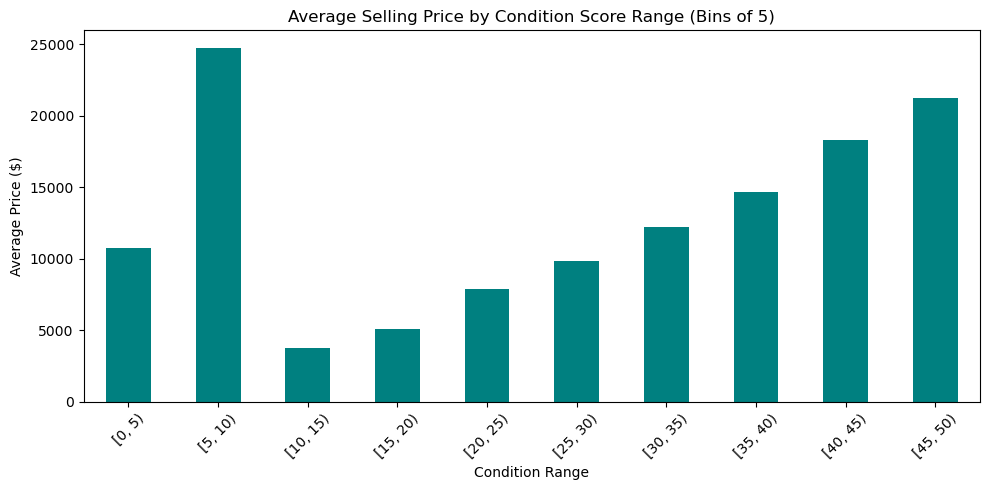

In [25]:
df['cond_bin_5'] = pd.cut(df['condition'], bins=range(0, 55, 5), right=False)
cond_price_5 = df.groupby('cond_bin_5', observed=False)['sellingprice'].mean()

plt.figure(figsize=(10, 5))
cond_price_5.plot(kind='bar', color='teal')
plt.title("Average Selling Price by Condition Score Range (Bins of 5)")
plt.xlabel("Condition Range")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
Number of Cars Sold by Condition Score Ranges (Size 10)

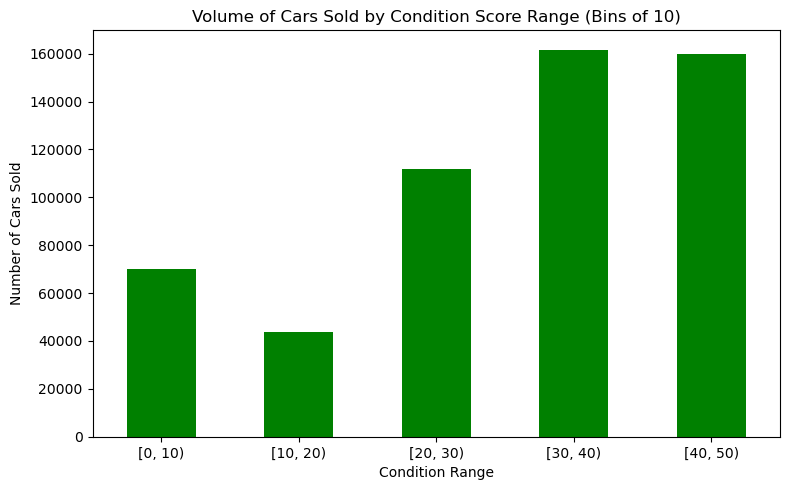

In [23]:
df['cond_bin_10'] = pd.cut(df['condition'], bins=range(0, 60, 10), right=False)
cond_count_10 = df.groupby('cond_bin_10', observed=False)['sellingprice'].count()

plt.figure(figsize=(8, 5))
cond_count_10.plot(kind='bar', color='Green')
plt.title("Volume of Cars Sold by Condition Score Range (Bins of 10)")
plt.xlabel("Condition Range")
plt.ylabel("Number of Cars Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
Box Plot: Price Distribution by Color (Before & After Outlier Removal)

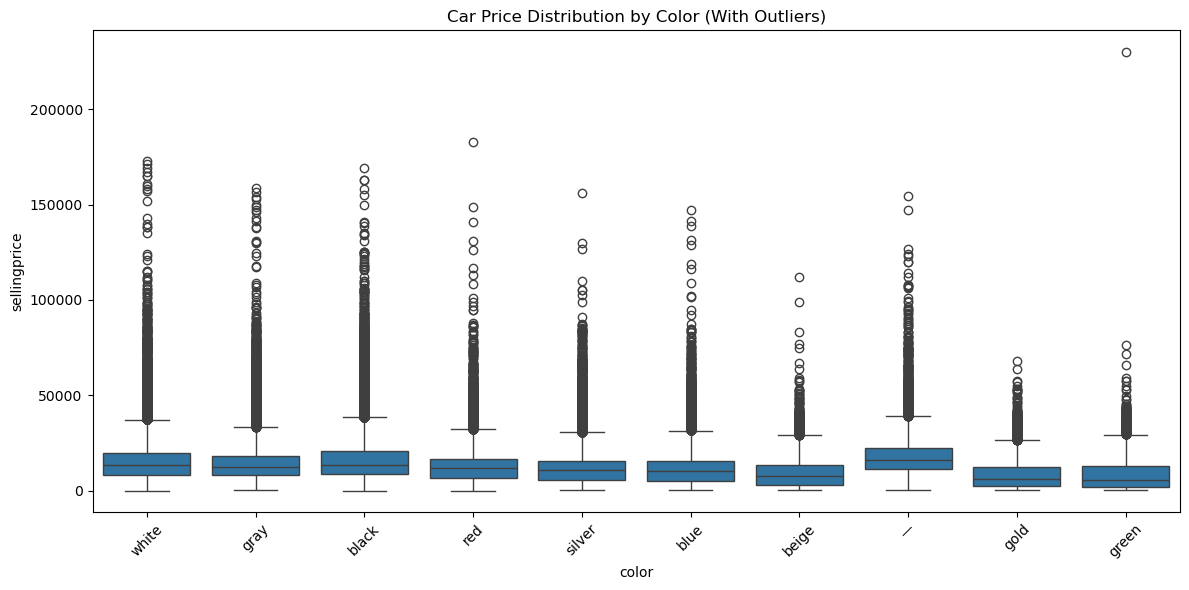

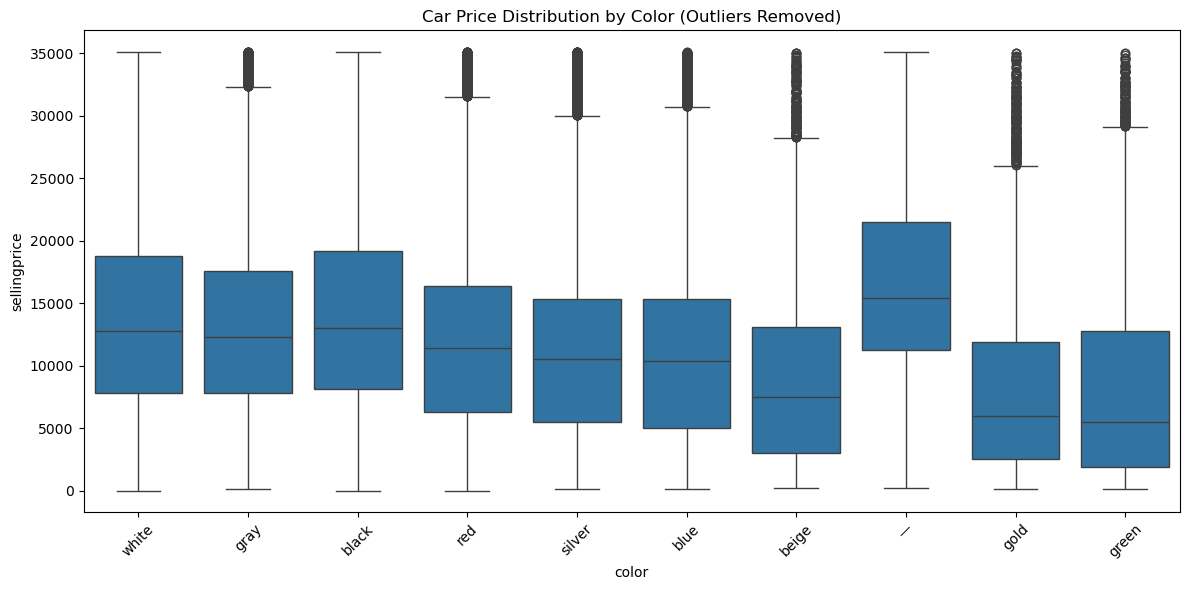

In [24]:
# 1. Box plot before outlier removal (Top 10 most common colors)
top_colors = df['color'].value_counts().head(10).index
df_top_colors = df[df['color'].isin(top_colors)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='color', y='sellingprice', data=df_top_colors)
plt.title("Car Price Distribution by Color (With Outliers)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Outlier removal using IQR method
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = max(0, Q1 - 1.5 * IQR)

df_no_outliers = df_top_colors[(df_top_colors['sellingprice'] >= lower_bound) & 
                               (df_top_colors['sellingprice'] <= upper_bound)]

# 3. Box plot after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(x='color', y='sellingprice', data=df_no_outliers)
plt.title("Car Price Distribution by Color (Outliers Removed)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Select key columns to export
output_filename = "car_prices_cleaned.csv"

# Drop temporary binning columns if not required
export_df = df.drop(columns=['cond_bin_5', 'cond_bin_10', 'odometer_bin'], errors='ignore')

# Save to CSV
export_df.to_csv(output_filename, index=False)
print(f"Successfully created outfile: '{output_filename}' with shape {export_df.shape}")

Successfully created outfile: 'car_prices_cleaned.csv' with shape (558837, 17)
